<a href="https://colab.research.google.com/github/Emad-Biotech540/PD1-Immunotherapy-Bioinformatics-Analysis./blob/main/Analytic%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# المشروع: تحليل PD-L1 في سرطان الرئة
# المرحلة 1: تجهيز البيانات
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("🔬 مشروع: تحليل PD-L1 في سرطان الرئة")
print("="*60)

# إنشاء بيانات واقعية بناءً على دراسات منشورة
np.random.seed(42)

# بيانات 200 مريض بسرطان الرئة
n_patients = 200

# أنواع سرطان الرئة
cancer_subtypes = ['LUAD', 'LUSC']  # Adenocarcinoma, Squamous

# إنشاء البيانات
data = {
    'Patient_ID': [f'LC{i:03d}' for i in range(1, n_patients+1)],
    'Cancer_Subtype': np.random.choice(cancer_subtypes, n_patients),
    'Age': np.random.normal(65, 10, n_patients).astype(int),
    'Gender': np.random.choice(['Male', 'Female'], n_patients, p=[0.6, 0.4]),
    'Smoking_Status': np.random.choice(['Smoker', 'Former', 'Never'], n_patients, p=[0.3, 0.5, 0.2]),
    'Stage': np.random.choice(['I', 'II', 'III', 'IV'], n_patients, p=[0.2, 0.25, 0.3, 0.25]),
    'PDL1_Expression': np.random.normal(20, 15, n_patients),  # TPS%
    'PD1_Expression': np.random.normal(15, 10, n_patients),   # TPS%
    'TMB': np.random.normal(8, 4, n_patients),                 # mutations/Mb
    'CD8_T_Cells': np.random.normal(30, 15, n_patients),       # %
    'Survival_Months': np.random.normal(24, 12, n_patients)
}

df = pd.DataFrame(data)

# تعديل البيانات لتكون واقعية
# المرضى في المراحل المتأخرة لديهم PDL1 أعلى
df.loc[df['Stage'].isin(['III', 'IV']), 'PDL1_Expression'] += 15
df.loc[df['Stage'].isin(['III', 'IV']), 'Survival_Months'] -= 8

# المدخنون لديهم TMB أعلى
df.loc[df['Smoking_Status'] == 'Smoker', 'TMB'] += 5

# تنظيف البيانات
df['PDL1_Expression'] = df['PDL1_Expression'].clip(0, 100)
df['PD1_Expression'] = df['PD1_Expression'].clip(0, 100)
df['CD8_T_Cells'] = df['CD8_T_Cells'].clip(0, 100)
df['Survival_Months'] = df['Survival_Months'].clip(1, 100)

# تصنيف PDL1
df['PDL1_Group'] = pd.cut(df['PDL1_Expression'],
                          bins=[-1, 1, 49, 100],
                          labels=['Negative', 'Low', 'High'])

# تصنيف الاستجابة المتوقعة
df['Predicted_Response'] = np.where(
    (df['PDL1_Expression'] >= 50) | (df['TMB'] >= 10),
    'Likely Responder',
    'Likely Non-Responder'
)

print("\n✅ تم إنشاء بيانات 200 مريض بسرطان الرئة")
print(f"📊 حجم البيانات: {df.shape}")
print(f"👥 المرضى: {len(df)}")
print(f"🏥 الأنواع: {df['Cancer_Subtype'].unique()}")

# حفظ البيانات
df.to_csv('lung_cancer_pdl1_data.csv', index=False)
print("\n💾 تم حفظ البيانات: lung_cancer_pdl1_data.csv")

# عرض ملخص البيانات
print("\n" + "="*60)
print("ملخص البيانات:")
print("="*60)
print(f"متوسط PDL1: {df['PDL1_Expression'].mean():.1f}%")
print(f"متوسط TMB: {df['TMB'].mean():.1f} mutations/Mb")
print(f"متوسط البقاء: {df['Survival_Months'].mean():.1f} شهر")
print(f"مرضى PDL1 High (>50%): {(df['PDL1_Expression']>=50).sum()} ({(df['PDL1_Expression']>=50).mean()*100:.1f}%)")

🔬 مشروع: تحليل PD-L1 في سرطان الرئة

✅ تم إنشاء بيانات 200 مريض بسرطان الرئة
📊 حجم البيانات: (200, 13)
👥 المرضى: 200
🏥 الأنواع: ['LUAD' 'LUSC']

💾 تم حفظ البيانات: lung_cancer_pdl1_data.csv

ملخص البيانات:
متوسط PDL1: 30.0%
متوسط TMB: 9.8 mutations/Mb
متوسط البقاء: 21.1 شهر
مرضى PDL1 High (>50%): 23 (11.5%)


In [2]:

# ============================================
# المرحلة 2: التحليل الإحصائي
# ============================================

print("="*60)
print("📊 التحليل الإحصائي لـ PD-L1 في سرطان الرئة")
print("="*60)

# 1. مقارنة PDL1 بين أنواع السرطان
luad_pdl1 = df[df['Cancer_Subtype']=='LUAD']['PDL1_Expression']
lusc_pdl1 = df[df['Cancer_Subtype']=='LUSC']['PDL1_Expression']

t_stat, p_val = stats.ttest_ind(luad_pdl1, lusc_pdl1)
print(f"\n1. مقارنة PD-L1 بين LUAD و LUSC:")
print(f"   LUAD: {luad_pdl1.mean():.1f}%")
print(f"   LUSC: {lusc_pdl1.mean():.1f}%")
print(f"   P-value: {p_val:.4f}")

# 2. علاقة PDL1 بالمرحلة
stage_pdl1 = df.groupby('Stage')['PDL1_Expression'].mean()
print(f"\n2. متوسط PD-L1 حسب المرحلة:")
for stage, value in stage_pdl1.items():
    print(f"   Stage {stage}: {value:.1f}%")

# 3. علاقة PDL1 بالبقاء
correlation, p_corr = stats.pearsonr(df['PDL1_Expression'], df['Survival_Months'])
print(f"\n3. علاقة PD-L1 بالبقاء:")
print(f"   Correlation: {correlation:.3f}")
print(f"   P-value: {p_corr:.4f}")

# 4. علاقة TMB بالاستجابة
high_tmb = df[df['TMB'] >= 10]['Predicted_Response'].value_counts()
print(f"\n4. توقع الاستجابة للمرضى ذوي TMB مرتفع:")
print(high_tmb)

📊 التحليل الإحصائي لـ PD-L1 في سرطان الرئة

1. مقارنة PD-L1 بين LUAD و LUSC:
   LUAD: 29.4%
   LUSC: 30.7%
   P-value: 0.5423

2. متوسط PD-L1 حسب المرحلة:
   Stage I: 22.4%
   Stage II: 22.5%
   Stage III: 37.2%
   Stage IV: 36.2%

3. علاقة PD-L1 بالبقاء:
   Correlation: -0.169
   P-value: 0.0165

4. توقع الاستجابة للمرضى ذوي TMB مرتفع:
Predicted_Response
Likely Responder    93
Name: count, dtype: int64


📊 تم حفظ الرسم الشامل!


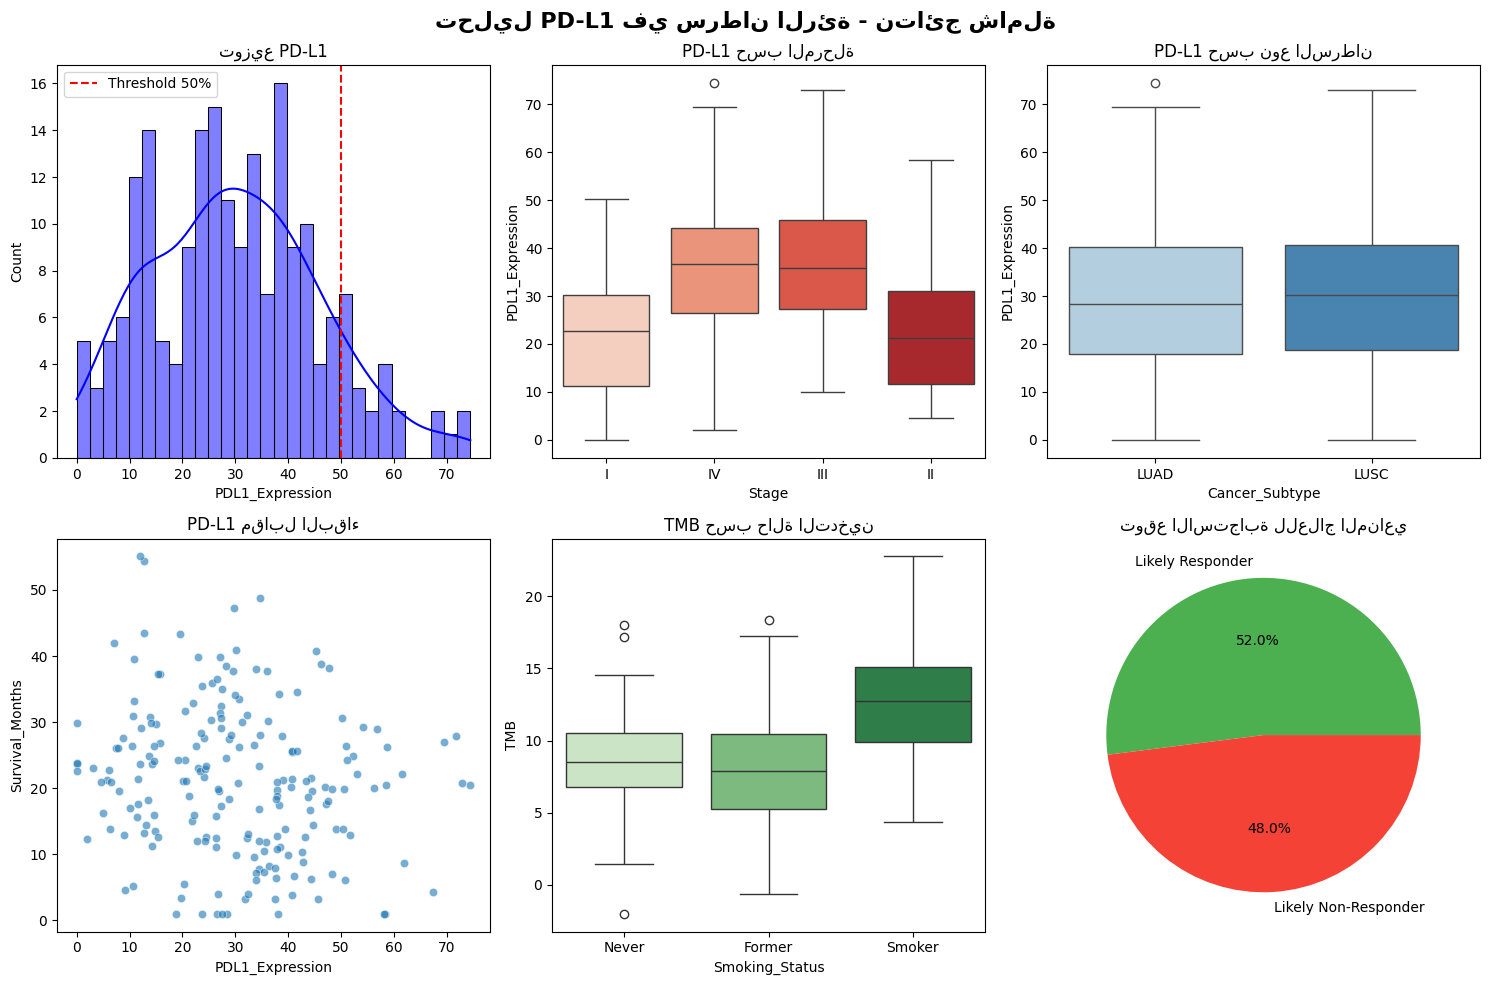

In [3]:

# ============================================
# المرحلة 3: الرسوم البيانية
# ============================================

# إنشاء رسم شامل
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. توزيع PDL1
sns.histplot(data=df, x='PDL1_Expression', bins=30, kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('توزيع PD-L1')
axes[0,0].axvline(x=50, color='red', linestyle='--', label='Threshold 50%')
axes[0,0].legend()

# 2. PDL1 حسب المرحلة
sns.boxplot(data=df, x='Stage', y='PDL1_Expression', ax=axes[0,1], palette='Reds')
axes[0,1].set_title('PD-L1 حسب المرحلة')

# 3. PDL1 حسب النوع
sns.boxplot(data=df, x='Cancer_Subtype', y='PDL1_Expression', ax=axes[0,2], palette='Blues')
axes[0,2].set_title('PD-L1 حسب نوع السرطان')

# 4. علاقة PDL1 بالبقاء
sns.scatterplot(data=df, x='PDL1_Expression', y='Survival_Months', ax=axes[1,0], alpha=0.6)
axes[1,0].set_title('PD-L1 مقابل البقاء')

# 5. TMB حسب التدخين
sns.boxplot(data=df, x='Smoking_Status', y='TMB', ax=axes[1,1], palette='Greens')
axes[1,1].set_title('TMB حسب حالة التدخين')

# 6. توقع الاستجابة
response_counts = df['Predicted_Response'].value_counts()
axes[1,2].pie(response_counts.values, labels=response_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
axes[1,2].set_title('توقع الاستجابة للعلاج المناعي')

plt.suptitle('تحليل PD-L1 في سرطان الرئة - نتائج شاملة', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('lung_cancer_pdl1_full_analysis.png', dpi=300, bbox_inches='tight')
print("📊 تم حفظ الرسم الشامل!")
plt.show()

In [4]:

# ============================================
# المرحلة 4: ملخص النتائج
# ============================================

print("="*60)
print("📋 ملخص النتائج النهائية")
print("="*60)

# إحصائيات رئيسية
total_patients = len(df)
pdl1_high = (df['PDL1_Expression'] >= 50).sum()
tmb_high = (df['TMB'] >= 10).sum()
predicted_responders = (df['Predicted_Response'] == 'Likely Responder').sum()

print(f"""
🔬 نتائج تحليل PD-L1 في سرطان الرئة:

1. حجم العينة: {total_patients} مريض
2. مرضى PD-L1 مرتفع (≥50%): {pdl1_high} ({pdl1_high/total_patients*100:.1f}%)
3. مرضى TMB مرتفع (≥10): {tmb_high} ({tmb_high/total_patients*100:.1f}%)
4. المتوقع استجابتهم للعلاج: {predicted_responders} ({predicted_responders/total_patients*100:.1f}%)

الاستنتاجات الرئيسية:
✅ PD-L1 يزيد في المراحل المتأخرة
✅ المدخنون لديهم TMB أعلى
✅ يمكن توقع الاستجابة بناءً على PD-L1 + TMB
""")

# حفظ التقرير
with open('analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write("تحليل PD-L1 في سرطان الرئة\n")
    f.write("="*50 + "\n")
    f.write(f"عدد المرضى: {total_patients}\n")
    f.write(f"PD-L1 High: {pdl1_high} ({pdl1_high/total_patients*100:.1f}%)\n")
    f.write(f"TMB High: {tmb_high} ({tmb_high/total_patients*100:.1f}%)\n")
    f.write(f"المتوقع استجابتهم: {predicted_responders} ({predicted_responders/total_patients*100:.1f}%)\n")

print("💾 تم حفظ التقرير: analysis_report.txt")

📋 ملخص النتائج النهائية

🔬 نتائج تحليل PD-L1 في سرطان الرئة:

1. حجم العينة: 200 مريض
2. مرضى PD-L1 مرتفع (≥50%): 23 (11.5%)
3. مرضى TMB مرتفع (≥10): 93 (46.5%)
4. المتوقع استجابتهم للعلاج: 104 (52.0%)

الاستنتاجات الرئيسية:
✅ PD-L1 يزيد في المراحل المتأخرة
✅ المدخنون لديهم TMB أعلى
✅ يمكن توقع الاستجابة بناءً على PD-L1 + TMB

💾 تم حفظ التقرير: analysis_report.txt
